<a href="https://colab.research.google.com/github/ruslanleker1663/MLBB-MachineLearningBelajarBareng/blob/main/MLBB003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('/content/language_native.csv')

In [8]:
df.head(5)

,Full Name,TOEIC,TOEFL iBT,IELTS,HSK,JLPT,Eng Level,Other
0,Jansen Benjamin Angelo,955,117,8.0,4,N3,C1,"Deutcheland - B2, Latin - C1"
1,Jasmine Benjamin Angela,955,117,8.0,5,N2,C1,"Deutcheland - B2, Latin - C1"
2,Paola Felisitas Oryza,960,118,8.5,5,N2,C2,"Francis - C1, Latin - C1, Deutcheland - C1"
3,Philipa Sophia Larasti,970,118,9.0,4,N3,C2,"Francis - C1, Latin - C2"
4,Azzuri Zoraya Dimaria,960,118,8.5,6,N2,C2,"Francis - C1, Latin - C1"


data inspection

In [9]:
df.shape

(24, 8)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Full Name  24 non-null     object 
 1   TOEIC      24 non-null     int64  
 2   TOEFL iBT  24 non-null     int64  
 3   IELTS      24 non-null     float64
 4   HSK        24 non-null     int64  
 5   JLPT       24 non-null     object 
 6   Eng Level  24 non-null     object 
 7   Other      24 non-null     object 
dtypes: float64(1), int64(3), object(4)
memory usage: 1.6+ KB


In [11]:
df.isnull().sum()

,0
Full Name,0
TOEIC,0
TOEFL iBT,0
IELTS,0
HSK,0
JLPT,0
Eng Level,0
Other,0


In [13]:
df.describe()

,TOEIC,TOEFL iBT,IELTS,HSK
count,24.0000,24.000000,24.000000,24.000000
mean,961.8750,117.541667,8.520833,4.916667
std,7.3444,1.933215,0.429336,0.717282
min,950.0000,112.000000,7.500000,4.000000
25%,955.0000,117.000000,8.375000,4.000000
50%,960.0000,118.000000,8.500000,5.000000
75%,970.0000,118.000000,9.000000,5.000000
max,970.0000,120.000000,9.000000,6.000000


visual inspect

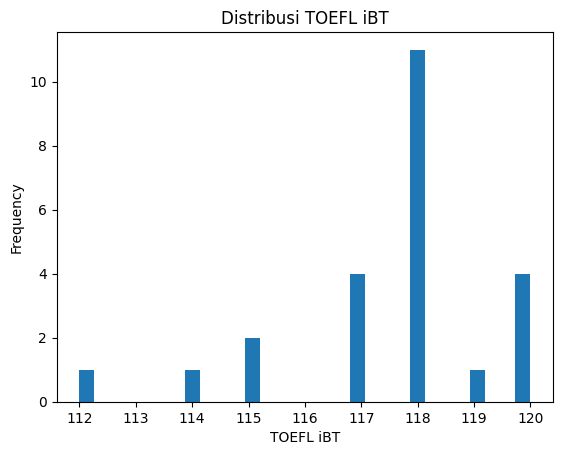

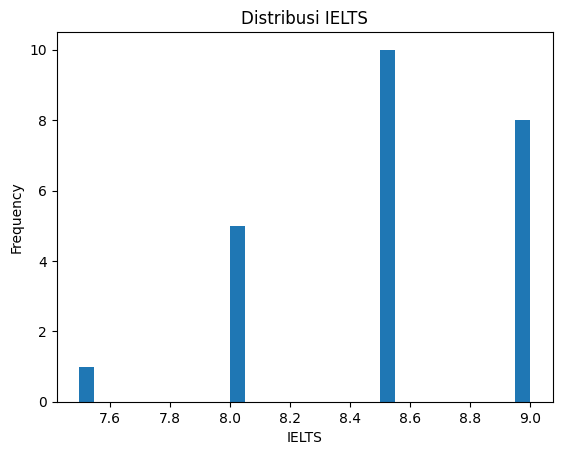

In [17]:
num_cols = ['TOEFL iBT', 'IELTS']
for col in num_cols:
  plt.figure()
  plt.hist(df[col], bins=30)
  plt.title(f'Distribusi {col}')
  plt.xlabel(col);plt.ylabel('Frequency')
  plt.show()

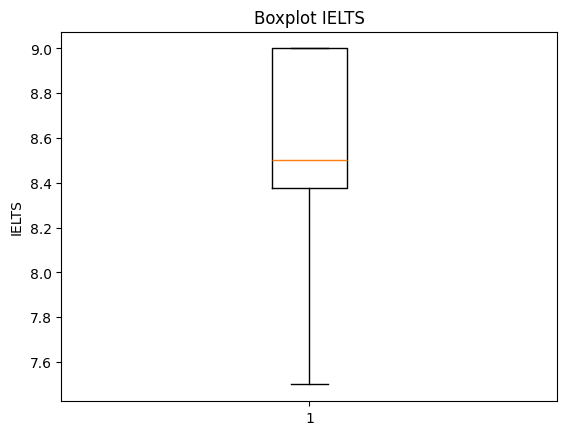

In [18]:
plt.figure()
plt.boxplot(df['IELTS'].dropna(), vert=True)
plt.title('Boxplot IELTS')
plt.ylabel('IELTS')
plt.show()

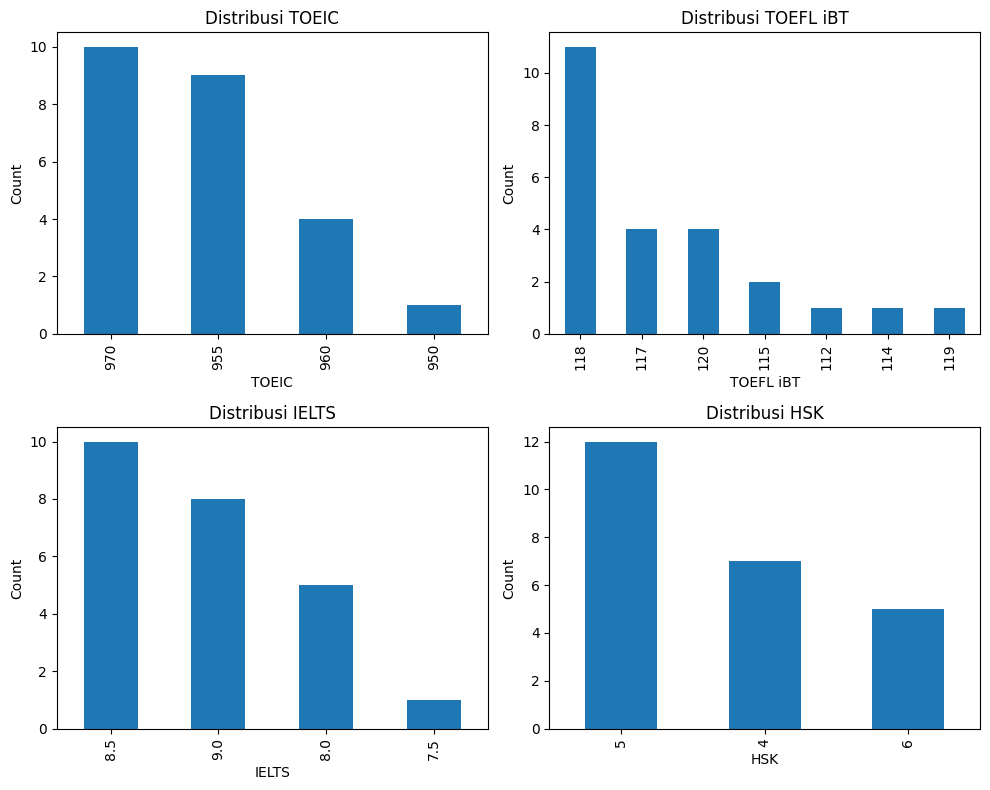

In [19]:
cat_cols = ['TOEIC', 'TOEFL iBT', 'IELTS', 'HSK']

fig, axes = plt.subplots(2,2,figsize=(10,8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
  df[col].value_counts(dropna=False).plot(kind='bar', ax=axes[i])
  axes[i].set_title(f'Distribusi {col}')
  axes[i].set_xlabel(col)
  axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

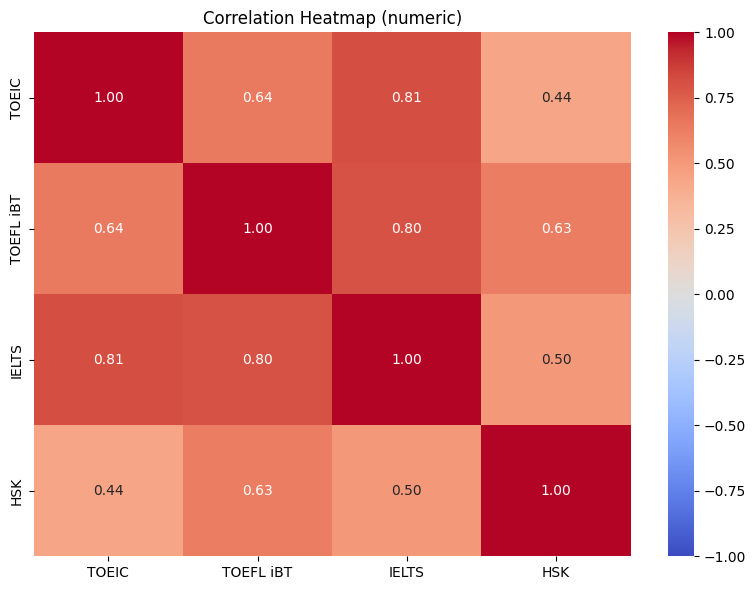

In [20]:
import seaborn as sns # Import seaborn for enhanced visualization

num_only = df.select_dtypes(include=[np.number])
corr = num_only.corr(numeric_only=True)

plt.figure(figsize=(8, 6)) # Increased figure size for better readability
sns.heatmap(corr, cmap='coolwarm', vmin=-1, vmax=1, annot=True, fmt=".2f") # Use seaborn.heatmap with annotation
plt.title('Correlation Heatmap (numeric)')
plt.tight_layout()
plt.show()

In [21]:
corr['HSK'].sort_values(ascending=False)

,HSK
HSK,1.000000
TOEFL iBT,0.629707
IELTS,0.500026
TOEIC,0.443613


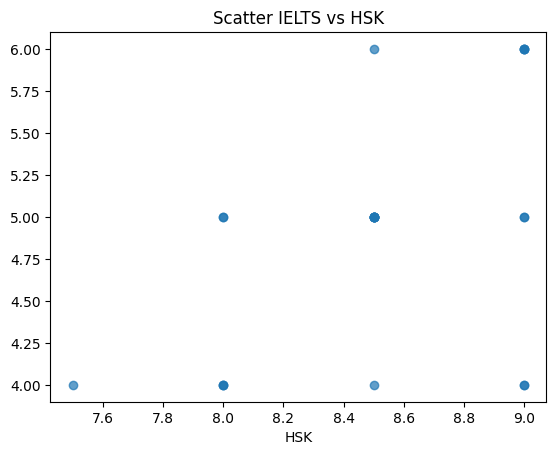

In [23]:
plt.figure()
Surv_map = {0: 'No', 1:'Yes'}
plt.scatter(df['IELTS'], df['HSK'], alpha=0.7)
plt.xlabel('HSK')
plt.title('Scatter IELTS vs HSK')
plt.show()